## 1. Importações

Carregamento das bibliotecas principais utilizadas no pipeline: manipulação de dados (`pandas`, `numpy`), divisão de conjuntos de treino/teste (`train_test_split`) e os primeiros algoritmos de classificação.

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report


## 2. Carregamento e Preparação dos Dados

Leitura do dataset em formato Parquet e filtragem inicial: mantém apenas registros com `Desired_Savings > 0`, garantindo que apenas clientes com meta de poupança definida entrem na análise.

In [12]:
df = pd.read_parquet('../../dataset/data.parquet', engine='fastparquet')
df = df[df['Desired_Savings'] > 0].copy()


## 3. Definição da Variável Alvo (`Vulnerable`)

Cálculo do gabarito oficial de vulnerabilidade financeira. Um cliente é classificado como vulnerável (`1`) quando atende pelo menos 2 dos 4 critérios de risco: comprometimento elevado com empréstimo, alto gasto com não-essenciais, margem disponível insuficiente, ou potencial de economia em supermercado acima do limite.

In [13]:
df['perc_nao_essenciais'] = (df['Eating_Out'] + df['Entertainment']) / df['Income']
df['perc_emprestimo'] = df['Loan_Repayment'] / df['Income']
df['Vulnerable'] = ((df['perc_emprestimo'] > 0.10).astype(int) + 
                    (df['perc_nao_essenciais'] > 0.085).astype(int) + 
                    ((df['Disposable_Income'] - df['Desired_Savings']) / df['Income'] < 0.10).astype(int) + 
                    (df['Potential_Savings_Groceries'] / df['Income'] > 0.08).astype(int) >= 2).astype(int)


## 4. Engenharia de Features

Criação de variáveis percentuais normalizadas pela renda (`Income`). Essa transformação elimina o efeito de escala absoluta dos valores e torna os atributos comparáveis entre clientes de diferentes faixas de renda. As variáveis cobrem despesas essenciais (aluguel, saúde, educação) e de comportamento (alimentação, transporte, utilidades, seguro).

In [14]:
df['Rent_Ratio'] = df['Rent'] / df['Income']
df['Healthcare_Ratio'] = df['Healthcare'] / df['Income']
df['Education_Ratio'] = df['Education'] / df['Income']
df['Groceries_Ratio'] = df['Groceries'] / df['Income']
df['Transport_Ratio'] = df['Transport'] / df['Income']
df['Utilities_Ratio'] = df['Utilities'] / df['Income']
df['Insurance_Ratio'] = df['Insurance'] / df['Income']


## 5. Seleção de Features e Divisão Treino/Teste

Definição do conjunto final de features sem vazamento de informação (*data leakage*): variáveis como `perc_emprestimo` são excluídas por estarem presentes na fórmula do target. A divisão usa estratificação para preservar a proporção das classes em treino e teste.

In [15]:

features_percentuais = [
    'Age', 
    'Dependents', 
    'Rent_Ratio', 
    'Healthcare_Ratio', 
    'Education_Ratio', 
    'Groceries_Ratio',
    'Transport_Ratio',
    'Utilities_Ratio',
    'Insurance_Ratio'
]

X = df[features_percentuais]
y = df['Vulnerable']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 6. Análise de Correlação entre Features

Heatmap da matriz de correlação de Pearson entre as features selecionadas. O objetivo é identificar multicolinearidade (correlações absolutas acima de 0.7) que possam comprometer modelos sensíveis à redundância entre variáveis, como a Regressão Logística e o SVM.

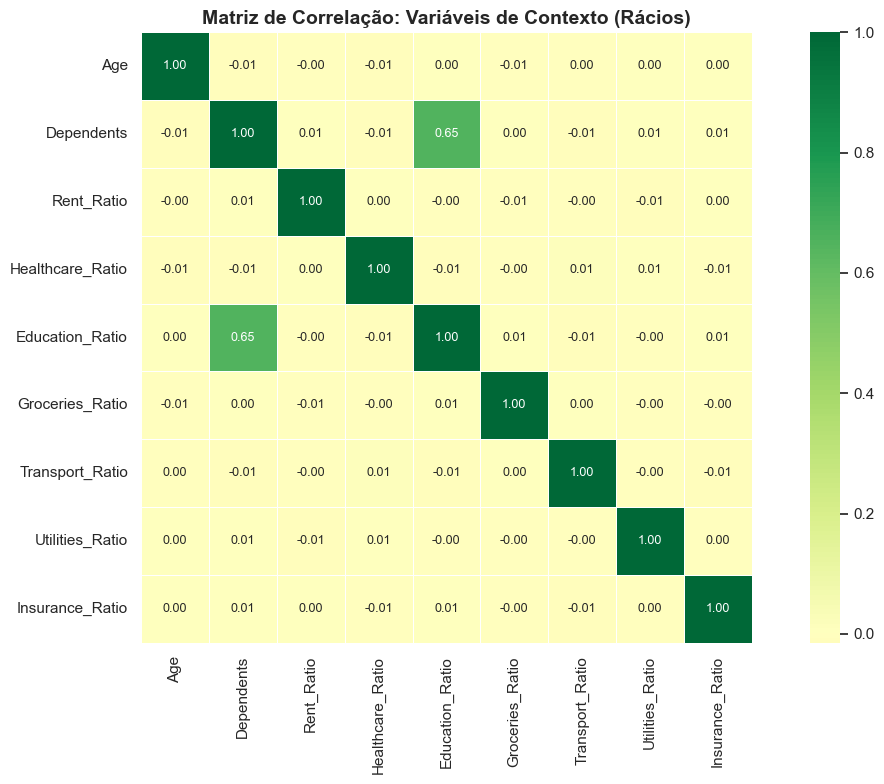


 ALERTA DE MULTICOLINEARIDADE (Correlação > 0.7 ou < -0.7) 
------------------------------------------------------------


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

features_percentuais = [
    'Age',
    'Dependents',
    'Rent_Ratio',
    'Healthcare_Ratio',
    'Education_Ratio',
    'Groceries_Ratio',
    'Transport_Ratio',
    'Utilities_Ratio',
    'Insurance_Ratio'
]

X_corr = df[features_percentuais]
corr_matrix = X_corr.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 9}
)
plt.title('Matriz de Correlação: Variáveis de Contexto (Rácios)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n ALERTA DE MULTICOLINEARIDADE (Correlação > 0.7 ou < -0.7) ")
print("------------------------------------------------------------")
for col in corr_matrix.columns:
    for row in corr_matrix.index:
        if col != row and abs(corr_matrix.loc[row, col]) > 0.7:
            if list(corr_matrix.columns).index(row) > list(corr_matrix.columns).index(col):
                print(f"  {row} ↔ {col}: {corr_matrix.loc[row, col]:.2f}")

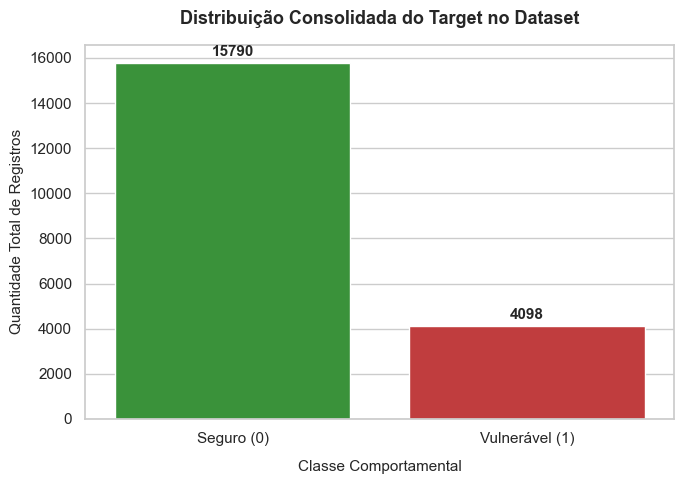

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))


ax = sns.countplot(
    x='Vulnerable', 
    data=df, 
    palette=['#2ca02c', '#d62728'], 
    hue='Vulnerable',
    legend=False
)


for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        ax.annotate(
            f'{int(altura)}', 
            (p.get_x() + p.get_width() / 2., altura), 
            ha='center', 
            va='center', 
            xytext=(0, 8), 
            textcoords='offset points',
            fontweight='bold',
            fontsize=11
        )


plt.title('Distribuição Consolidada do Target no Dataset', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Classe Comportamental', fontsize=11, labelpad=10)
plt.ylabel('Quantidade Total de Registros', fontsize=11)
plt.xticks(ticks=[0, 1], labels=['Seguro (0)', 'Vulnerável (1)'], fontsize=11)

plt.tight_layout()
plt.show()

## 7. Treinamento e Avaliação de Múltiplos Modelos

Treinamento paralelo de seis algoritmos de classificação: Regressão Logística, Random Forest, Gradient Boosting, XGBoost, SVM e CatBoost. Todos recebem pesos de classe ajustados para compensar o desbalanceamento entre `Seguro` e `Vulnerável`. O SVM passa por um pipeline com `StandardScaler` por exigir dados normalizados. A avaliação inclui `classification_report` e AUC-ROC para cada modelo.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, roc_auc_score

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
ratio = n_neg / n_pos

modelos = {
    'Regressão Logística': LogisticRegression(random_state=42, class_weight={0: 1, 1: ratio * 0.8}, max_iter=1000),
    'Regressão Logística-teste 1': LogisticRegression(random_state=42, class_weight={0: 1, 1: ratio * 0.8}, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight={0: 1, 1: ratio * 0.8}, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, subsample=0.8),
    'XGBoost': XGBClassifier(random_state=42, scale_pos_weight=ratio * 0.8, min_child_weight=5, max_depth=5),
    'SVM': make_pipeline(StandardScaler(), SVC(probability=True, random_state=42, class_weight={0: 1, 1: ratio * 0.8})),
    'CatBoost': CatBoostClassifier(random_state=42, class_weights=[1, ratio * 0.8], verbose=0)
}

print(f"🔄 Treinando {len(modelos)} algoritmos de alta performance...\n")

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    y_prob = modelo.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)

    print(f"{'='*60}")
    print(f" ALGORITMO: {nome}")
    print(f" AUC-ROC: {auc:.4f}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, target_names=['Seguro', 'Vulnerável']))
    print("\n")

🔄 Treinando 6 algoritmos de alta performance...

 ALGORITMO: Regressão Logística
 AUC-ROC: 0.6529
              precision    recall  f1-score   support

      Seguro       0.83      0.80      0.81      3158
  Vulnerável       0.31      0.35      0.33       820

    accuracy                           0.71      3978
   macro avg       0.57      0.57      0.57      3978
weighted avg       0.72      0.71      0.71      3978



 ALGORITMO: Random Forest
 AUC-ROC: 0.6144
              precision    recall  f1-score   support

      Seguro       0.80      1.00      0.88      3158
  Vulnerável       0.53      0.01      0.02       820

    accuracy                           0.79      3978
   macro avg       0.66      0.50      0.45      3978
weighted avg       0.74      0.79      0.71      3978



 ALGORITMO: Gradient Boosting
 AUC-ROC: 0.6512
              precision    recall  f1-score   support

      Seguro       0.79      1.00      0.88      3158
  Vulnerável       0.33      0.00      0.00  

## 8. Tabela Consolidada de Métricas por Modelo

Formatação e exibição de uma tabela unificada com Precisão, Recall, F1-Score, Suporte e Acurácia para todos os modelos treinados, discriminando as classes `Seguro (0)` e `Vulnerável (1)`. Facilita a comparação visual entre algoritmos lado a lado.

In [19]:
from sklearn.metrics import classification_report
import pandas as pd

def formatar_resultado(nome_modelo, y_test, y_pred):
    report = classification_report(
        y_test, y_pred,
        target_names=['Seguro', 'Vulnerável'],
        output_dict=True
    )

    def fmt(v):
        return f"{v:.3f}".replace('.', ',')

    rows = [
        {
            'Modelo': nome_modelo,
            'Métrica': 'Precisão',
            'Seguro (0)': fmt(report['Seguro']['precision']),
            'Vulnerável (1)': fmt(report['Vulnerável']['precision']),
            'Média': fmt(report['macro avg']['precision']),
            'Média Ponderada': fmt(report['weighted avg']['precision']),
        },
        {
            'Modelo': '',
            'Métrica': 'Recall',
            'Seguro (0)': fmt(report['Seguro']['recall']),
            'Vulnerável (1)': fmt(report['Vulnerável']['recall']),
            'Média': fmt(report['macro avg']['recall']),
            'Média Ponderada': fmt(report['weighted avg']['recall']),
        },
        {
            'Modelo': '',
            'Métrica': 'F1-Score',
            'Seguro (0)': fmt(report['Seguro']['f1-score']),
            'Vulnerável (1)': fmt(report['Vulnerável']['f1-score']),
            'Média': fmt(report['macro avg']['f1-score']),
            'Média Ponderada': fmt(report['weighted avg']['f1-score']),
        },
        {
            'Modelo': '',
            'Métrica': 'Suporte',
            'Seguro (0)': str(int(report['Seguro']['support'])),
            'Vulnerável (1)': str(int(report['Vulnerável']['support'])),
            'Média': str(int(report['Seguro']['support'] + report['Vulnerável']['support'])),
            'Média Ponderada': '—',
        },
        {
            'Modelo': '',
            'Métrica': 'Acurácia',
            'Seguro (0)': '—',
            'Vulnerável (1)': '—',
            'Média': fmt(report['accuracy']),
            'Média Ponderada': '—',
        },
    ]
    return pd.DataFrame(rows)


todas_tabelas = []
for nome, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    todas_tabelas.append(formatar_resultado(nome, y_test, y_pred))

resultado_final = pd.concat(todas_tabelas, ignore_index=True)
resultado_final = resultado_final.set_index(['Modelo', 'Métrica'])

display(resultado_final.style.set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]},
    {'selector': 'td', 'props': [('text-align', 'center')]},
]))

## 9. Cross-Validation — Regressão Logística (Recall e Precisão para Seguro)

Validação cruzada estratificada com 5 folds focada na classe `Seguro (0)`. Mede a estabilidade do modelo calculando Recall e Precisão médios com seus desvios-padrão, verificando se o desempenho observado no conjunto de teste se generaliza para novos dados.

In [20]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, recall_score, precision_score

modelo_lr_cv = LogisticRegression(random_state=42, class_weight={0: 1, 1: ratio * 0.8}, max_iter=1000)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'recall_seguro':   make_scorer(recall_score,    pos_label=0),
    'precision_seguro': make_scorer(precision_score, pos_label=0),
}

resultados_cv = cross_validate(modelo_lr_cv, X, y, cv=skf, scoring=scoring)

recall_medio   = resultados_cv['test_recall_seguro'].mean()
recall_std     = resultados_cv['test_recall_seguro'].std()
precisao_media = resultados_cv['test_precision_seguro'].mean()
precisao_std   = resultados_cv['test_precision_seguro'].std()

print("\n" + "="*50)
print("RESULTADO DO CROSS-VALIDATION (Regressão Logística)")
print("="*50)
print(f"🎯 Recall Médio   (Seguro): {recall_medio:.3f} (+/- {recall_std:.3f})")
print(f"🎯 Precisão Média (Seguro): {precisao_media:.3f} (+/- {precisao_std:.3f})")
print("="*50)


RESULTADO DO CROSS-VALIDATION (Regressão Logística)
🎯 Recall Médio   (Seguro): 0.794 (+/- 0.009)
🎯 Precisão Média (Seguro): 0.827 (+/- 0.003)


## 10. Matriz de Confusão — Regressão Logística

Visualização da matriz de confusão do modelo de Regressão Logística sobre o conjunto de teste. Permite identificar visualmente os verdadeiros positivos, falsos positivos, verdadeiros negativos e falsos negativos, essencial para avaliar o trade-off entre erros de classificação.

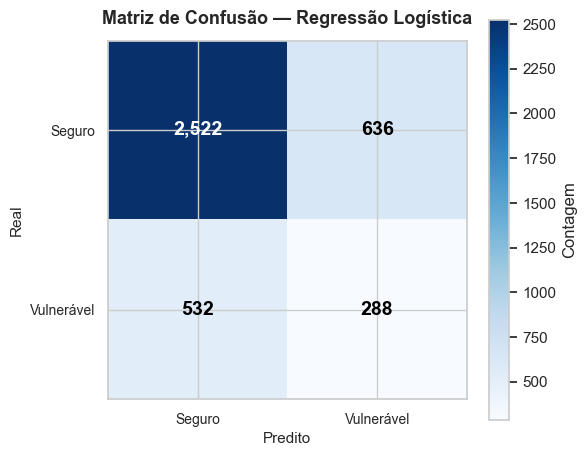

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

y_pred_lr = modelos['Regressão Logística'].predict(X_test)
cm = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax, label='Contagem')

ax.set_title('Matriz de Confusão — Regressão Logística', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Predito', fontsize=11)
ax.set_ylabel('Real', fontsize=11)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Seguro', 'Vulnerável'], fontsize=10)
ax.set_yticklabels(['Seguro', 'Vulnerável'], fontsize=10)

thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i, j]:,}',
                ha='center', va='center', fontsize=14, fontweight='bold',
                color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.savefig('matriz_confusao_lr.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Análise de Importância das Features com SHAP

Cálculo dos SHAP values (*SHapley Additive exPlanations*) para a Regressão Logística, com perspectiva invertida para a classe `Seguro`. Filtra apenas amostras verdadeiramente seguras e exibe um gráfico de barras horizontais com a importância média de cada feature na predição dessa classe.

c:\Users\mathe\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Background dataset has 15910 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=15910 when initializing the masker.


            feature  importancia
3  Healthcare_Ratio     0.004610
6   Transport_Ratio     0.013597
0               Age     0.015665
8   Insurance_Ratio     0.016474
1        Dependents     0.030818
7   Utilities_Ratio     0.035574
5   Groceries_Ratio     0.057370
4   Education_Ratio     0.185592
2        Rent_Ratio     0.284590


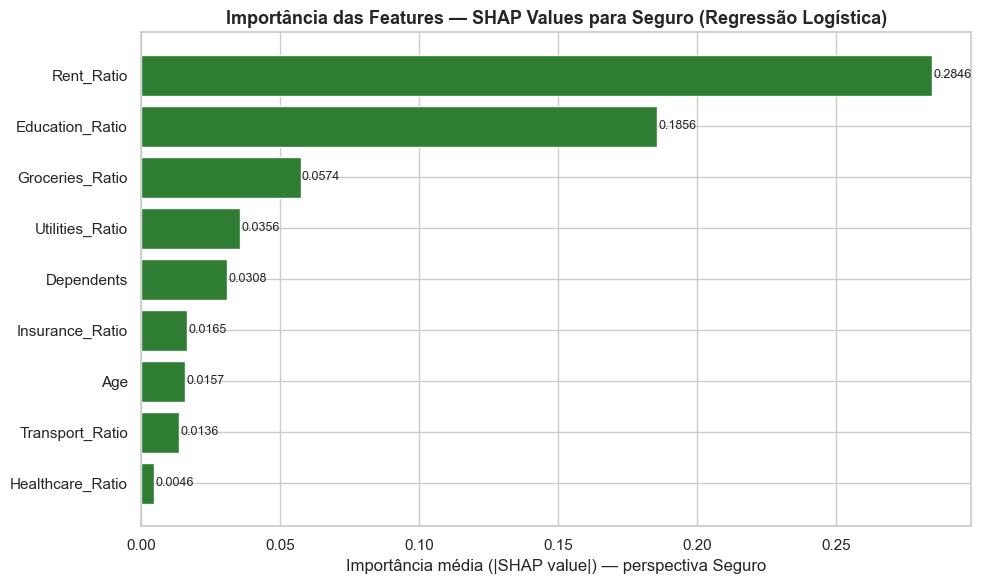

✅ Gráfico SHAP (Seguro) salvo!


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

modelo_lr = modelos['Regressão Logística']

explainer = shap.LinearExplainer(modelo_lr, X_train)
shap_values = explainer.shap_values(X_test)

sv_seguro = -shap_values

mask_seguro = (y_test == 0).values
sv_filtrado = sv_seguro[mask_seguro]

mean_shap = np.abs(sv_filtrado).mean(axis=0)
shap_df = pd.DataFrame({
    'feature': features_percentuais,
    'importancia': mean_shap
}).sort_values('importancia', ascending=True)

print(shap_df)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(shap_df['feature'], shap_df['importancia'], color='#2e7d32')
ax.set_title('Importância das Features — SHAP Values para Seguro (Regressão Logística)', fontweight='bold', fontsize=13)
ax.set_xlabel('Importância média (|SHAP value|) — perspectiva Seguro')

for i, v in enumerate(shap_df['importancia']):
    ax.text(v + 0.0005, i, f"{v:.4f}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig('shap_importancia_lr_seguro.png', dpi=150)
plt.show()
print("✅ Gráfico SHAP (Seguro) salvo!")

## 12. Análise de Pareto das Features (SHAP)

Visualização do Princípio de Pareto aplicado às importâncias SHAP da classe `Seguro`. O gráfico combinado mostra a contribuição individual de cada feature (barras) e a curva cumulativa, identificando quais variáveis respondem por 80% do poder explicativo do modelo.

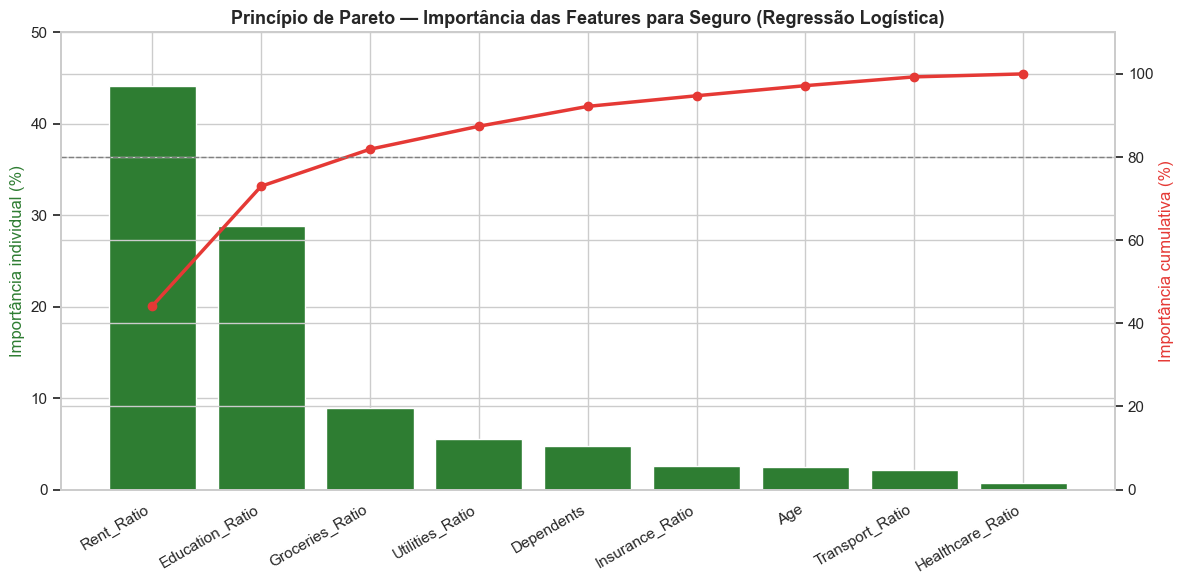

✅ Gráfico de Pareto (Seguro) salvo!


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

mean_shap = np.abs(sv_filtrado).mean(axis=0)

shap_df = pd.DataFrame({
    'feature': features_percentuais,
    'importancia': mean_shap
}).sort_values('importancia', ascending=False)

shap_df['importancia_pct'] = shap_df['importancia'] / shap_df['importancia'].sum() * 100
shap_df['cumulativo'] = shap_df['importancia_pct'].cumsum()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(shap_df['feature'], shap_df['importancia_pct'], color='#2e7d32', label='Importância %')
ax1.set_ylabel('Importância individual (%)', color='#2e7d32')
ax1.set_xticks(range(len(shap_df['feature'])))
ax1.set_xticklabels(shap_df['feature'], rotation=30, ha='right')
ax1.set_ylim(0, 50)

ax2 = ax1.twinx()
ax2.plot(shap_df['feature'], shap_df['cumulativo'], color='#e53935',
         marker='o', linewidth=2.5, label='Cumulativo %')
ax2.axhline(y=80, color='gray', linestyle='--', linewidth=1, label='80%')
ax2.set_ylabel('Importância cumulativa (%)', color='#e53935')
ax2.set_ylim(0, 110)

plt.title('Princípio de Pareto — Importância das Features para Seguro (Regressão Logística)', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('pareto_features_lr_seguro.png', dpi=150)
plt.show()
print("✅ Gráfico de Pareto (Seguro) salvo!")

## 13. Segmentação de Clientes por Probabilidade de Ser Seguro

Aplicação do modelo de Regressão Logística sobre toda a base para gerar a probabilidade individual de cada cliente ser `Seguro`. Os clientes são segmentados em três perfis — Alta, Moderada e Baixa confiança — com análise de renda média, empréstimo médio e exposição financeira mensal por grupo.

In [24]:
import pandas as pd
import numpy as np

modelo_lr = modelos['Regressão Logística']

X_completo = df[features_percentuais]
df['prob_seguro'] = modelo_lr.predict_proba(X_completo)[:, 0]

def classificar_seguro(prob):
    if prob >= 0.70:
        return 'Alta confiança'
    elif prob >= 0.40:
        return 'Moderada confiança'
    else:
        return 'Baixa confiança'

df['perfil_seguro'] = df['prob_seguro'].apply(classificar_seguro)

segmentacao = df.groupby('perfil_seguro').agg(
    clientes=('Income', 'count'),
    renda_media=('Income', 'mean'),
    emprestimo_medio=('Loan_Repayment', 'mean'),
    prob_media=('prob_seguro', 'mean')
).reindex(['Alta confiança', 'Moderada confiança', 'Baixa confiança'])

segmentacao['pct_base'] = (segmentacao['clientes'] / len(df) * 100).round(1)
segmentacao['exposicao_mensal'] = segmentacao['clientes'] * segmentacao['emprestimo_medio']

print("=" * 65)
print("  SELEÇÃO DE CLIENTES SEGUROS (Regressão Logística)")
print("=" * 65)
for perfil in ['Alta confiança', 'Moderada confiança', 'Baixa confiança']:
    row = segmentacao.loc[perfil]
    print(f"\n🔹 {perfil}:")
    print(f"   Clientes:               {int(row['clientes']):,}")
    print(f"   % da base:              {row['pct_base']}%")
    print(f"   Prob. média (Seguro):   {row['prob_media']*100:.1f}%")
    print(f"   Renda média:            R$ {row['renda_media']:,.0f}")
    print(f"   Empréstimo médio:       R$ {row['emprestimo_medio']:,.0f}")

alta = segmentacao.loc['Alta confiança']
print("\n" + "=" * 65)
print("  CLIENTES SELECIONÁVEIS — ALTA CONFIANÇA DE SER SEGURO")
print("=" * 65)
print(f"\n  Clientes elegíveis:         {int(alta['clientes']):,}")
print(f"  % da base:                  {alta['pct_base']}%")
print(f"  Prob. média de ser Seguro:  {alta['prob_media']*100:.1f}%")
print(f"  Exposição mensal total:     R$ {alta['exposicao_mensal']:,.0f}")

  SELEÇÃO DE CLIENTES SEGUROS (Regressão Logística)

🔹 Alta confiança:
   Clientes:               2,565
   % da base:              12.9%
   Prob. média (Seguro):   73.7%
   Renda média:            R$ 41,841
   Empréstimo médio:       R$ 2,054

🔹 Moderada confiança:
   Clientes:               15,118
   % da base:              76.0%
   Prob. média (Seguro):   56.9%
   Renda média:            R$ 41,434
   Empréstimo médio:       R$ 2,053

🔹 Baixa confiança:
   Clientes:               2,205
   % da base:              11.1%
   Prob. média (Seguro):   37.5%
   Renda média:            R$ 42,122
   Empréstimo médio:       R$ 1,702

  CLIENTES SELECIONÁVEIS — ALTA CONFIANÇA DE SER SEGURO

  Clientes elegíveis:         2,565
  % da base:                  12.9%
  Prob. média de ser Seguro:  73.7%
  Exposição mensal total:     R$ 5,267,240


## 14. Cross-Validation com Tabela Visual (Regressão Logística — 5 Folds)

Segunda rodada de validação cruzada, agora com métricas ampliadas (Precisão, Recall, F1-Score e Acurácia) para a classe `Seguro`. O resultado é exibido como uma tabela estilizada com médias e desvios-padrão, salva como imagem PNG para uso em relatórios.

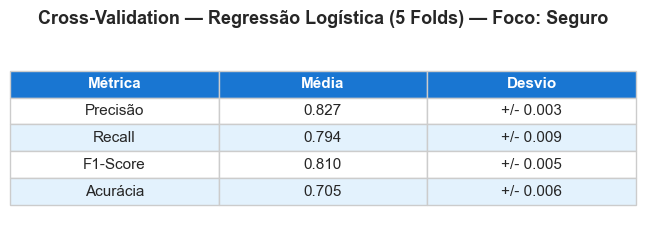

In [25]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, recall_score, precision_score, f1_score
import matplotlib.pyplot as plt
import pandas as pd

modelo_lr_cv2 = LogisticRegression(random_state=42, class_weight={0: 1, 1: ratio * 0.8}, max_iter=1000)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'precision': make_scorer(precision_score, pos_label=0),
    'recall':    make_scorer(recall_score,    pos_label=0),
    'f1':        make_scorer(f1_score,        pos_label=0),
    'accuracy':  'accuracy',
}

resultados_cv = cross_validate(modelo_lr_cv2, X, y, cv=skf, scoring=scoring)

dados = {
    'Métrica': ['Precisão', 'Recall', 'F1-Score', 'Acurácia'],
    'Média':   [f"{resultados_cv[f'test_{k}'].mean():.3f}" for k in ['precision', 'recall', 'f1', 'accuracy']],
    'Desvio':  [f"+/- {resultados_cv[f'test_{k}'].std():.3f}" for k in ['precision', 'recall', 'f1', 'accuracy']],
}

df_cv = pd.DataFrame(dados)

fig, ax = plt.subplots(figsize=(7, 2.5))
ax.axis('off')

tabela = ax.table(
    cellText=df_cv.values,
    colLabels=df_cv.columns,
    cellLoc='center',
    loc='center'
)

tabela.auto_set_font_size(False)
tabela.set_fontsize(11)
tabela.scale(1.4, 1.8)

for (row, col), cell in tabela.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1976d2')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#e3f2fd')
    else:
        cell.set_facecolor('white')
    cell.set_edgecolor('#cccccc')

ax.set_title('Cross-Validation — Regressão Logística (5 Folds) — Foco: Seguro',
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('cv_tabela_lr.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Tabela Comparativa Final — Todos os Modelos

Ranking final de todos os modelos treinados, ordenado pelo F1-Score para a classe `Seguro`. A tabela exibe Precisão, Recall e F1, formatados com vírgula decimal, e é exportada como imagem de alta resolução (300 DPI) para uso em apresentações e relatórios.

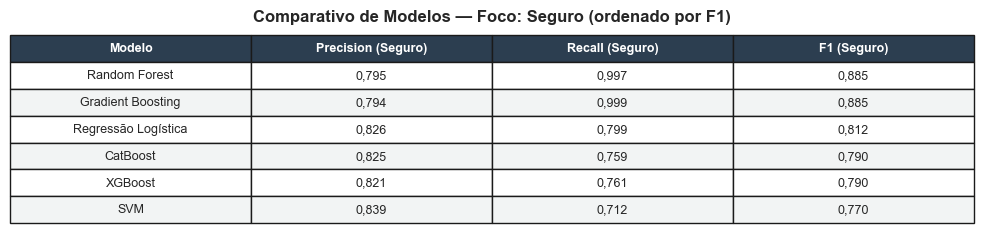

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

resultados = []
for nome, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    report = classification_report(y_test, y_pred, target_names=['Seguro', 'Vulnerável'], output_dict=True)
    resultados.append({
        'Modelo':             nome,
        'Precision (Seguro)': report['Seguro']['precision'],
        'Recall (Seguro)':    report['Seguro']['recall'],
        'F1 (Seguro)':        report['Seguro']['f1-score'],
    })

df_res = (pd.DataFrame(resultados)
            .sort_values('F1 (Seguro)', ascending=False)
            .reset_index(drop=True))

df_fmt = df_res.copy()
for col in df_fmt.columns[1:]:
    df_fmt[col] = df_fmt[col].map(lambda x: f"{x:.3f}".replace(".", ","))

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis("off")

tabela = ax.table(
    cellText=df_fmt.values,
    colLabels=df_fmt.columns,
    cellLoc="center",
    loc="center",
)
tabela.auto_set_font_size(False)
tabela.set_fontsize(9)
tabela.scale(1, 1.7)

for j in range(len(df_fmt.columns)):
    tabela[0, j].set_facecolor("#2C3E50")
    tabela[0, j].set_text_props(color="white", fontweight="bold")

for i in range(1, len(df_fmt) + 1):
    for j in range(len(df_fmt.columns)):
        tabela[i, j].set_facecolor("#F2F4F4" if i % 2 == 0 else "white")

plt.title("Comparativo de Modelos — Foco: Seguro (ordenado por F1)",
          fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("tabela_modelos_seguro.png", dpi=300, bbox_inches="tight")
plt.show()